In [1]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
import os
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

In [2]:
path = "/home/aadam/scratch/SKIRT_TNG/"

In [3]:
files = []
for d in tqdm(os.listdir(path)):
    for f in glob(os.path.join(path, d, "*.fits")):
        files.append(f)

100%|██████████| 7/7 [00:00<00:00, 14.74it/s]


# Prior sampling

In [2]:
from score_models import ScoreModel
from astropy.visualization import ImageNormalize, LogStretch
import torch
import os, json, re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_256_230523001306"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_64_230523001203"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_skirt_g_128_230523001212"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_probes_g_64_230604024652"

# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_skirt_g_64_230813171005"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_skirt_y_64_230813225149"
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_skirt_y_128_230813225201"
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_skirt_y_256_230813225247"

checkpoint_dir = "../models/ncsnpp_hst_b_unconditional"

model = ScoreModel(checkpoints_directory=checkpoint_dir)

print(f"Model has {sum([np.prod(p.shape) for p in model.parameters()]) / 1e6:.2f} parameters")

FileNotFoundError: [Errno 2] No such file or directory: '../models/ncsnpp_hst_b_unconditional/model_hparams.json'

In [10]:
W = 8
N = 2000
pixels = 256
samples = model.sample([W, 1, pixels, pixels], steps=N)

Sampling from the prior | t = 0.0 | sigma = 2.7e-03| scale ~ 4.8e+01: 100%|█████████▉| 1999/2000 [11:52<00:00,  2.81it/s]


In [6]:
# W = 64
# N = 2000
# pixels = 64
# samples = model.sample([W, 1, pixels, pixels], steps=N)

Sampling from the prior | t = 0.0 | sigma = 2.7e-03| scale ~ 9.0e+01: 100%|█████████▉| 1999/2000 [07:28<00:00,  4.45it/s]


# $64\times 64$ VP trained in linear space

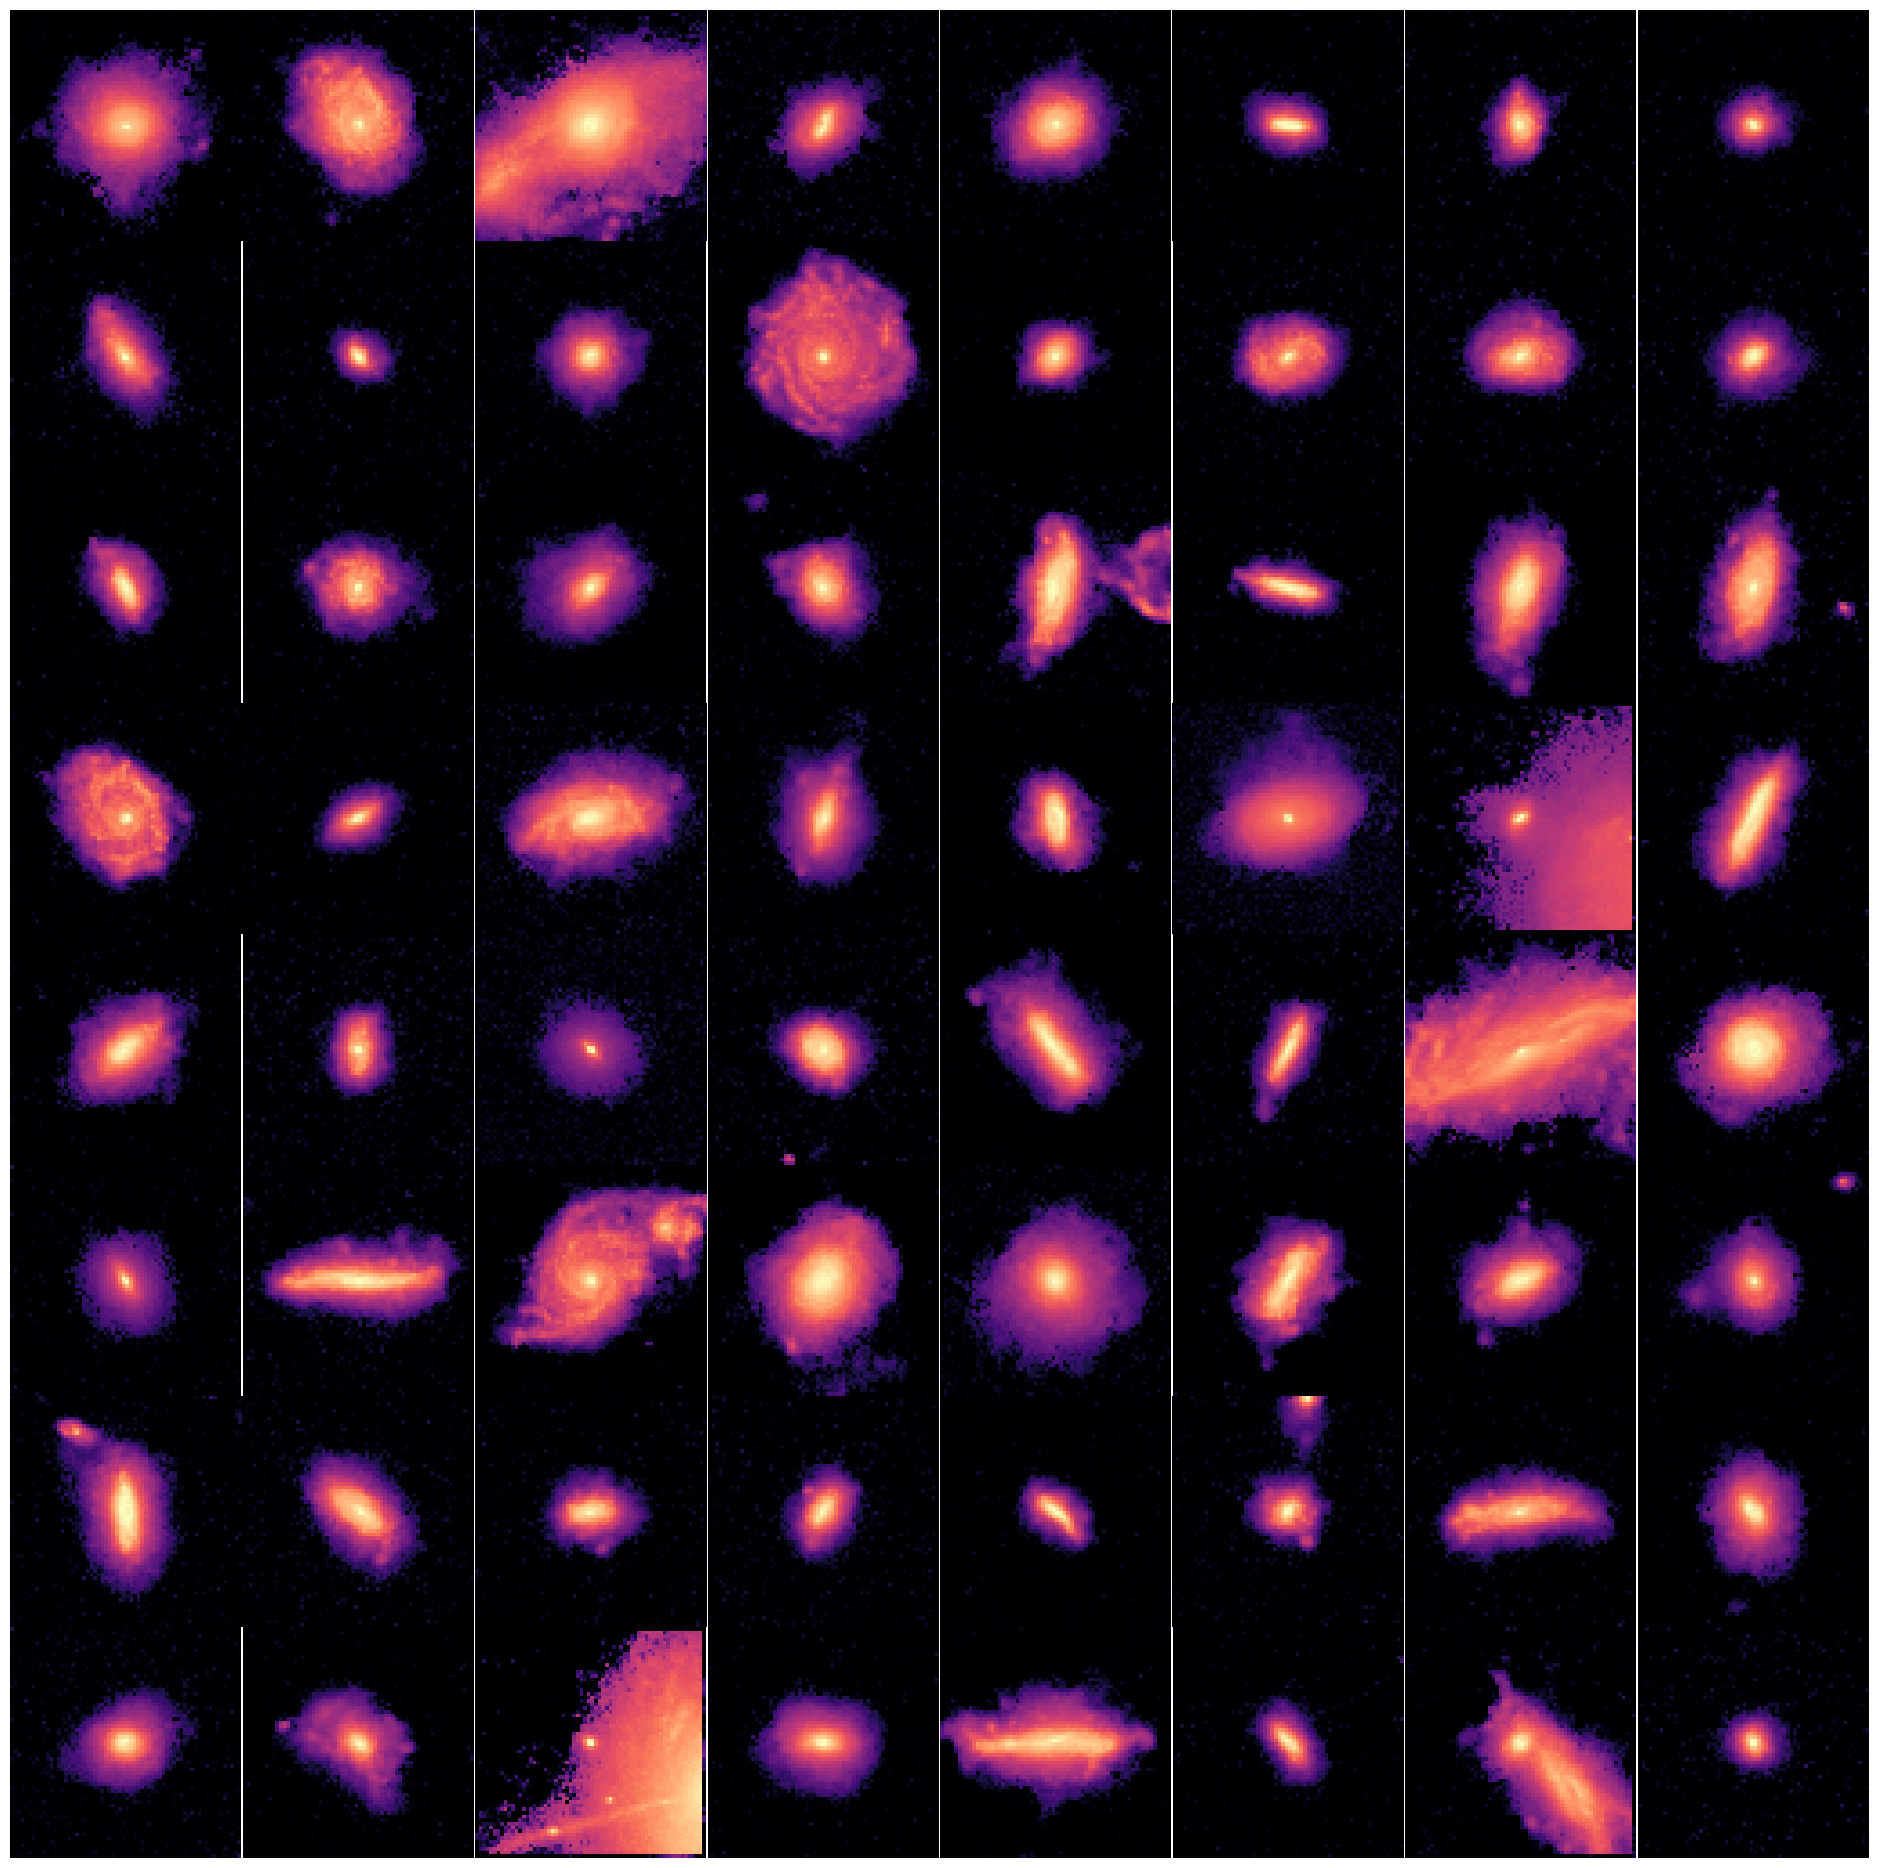

In [8]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = i * 8 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma", norm=plt.cm.colors.LogNorm(vmin=2e-3, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_skirt_vp64_y.png")

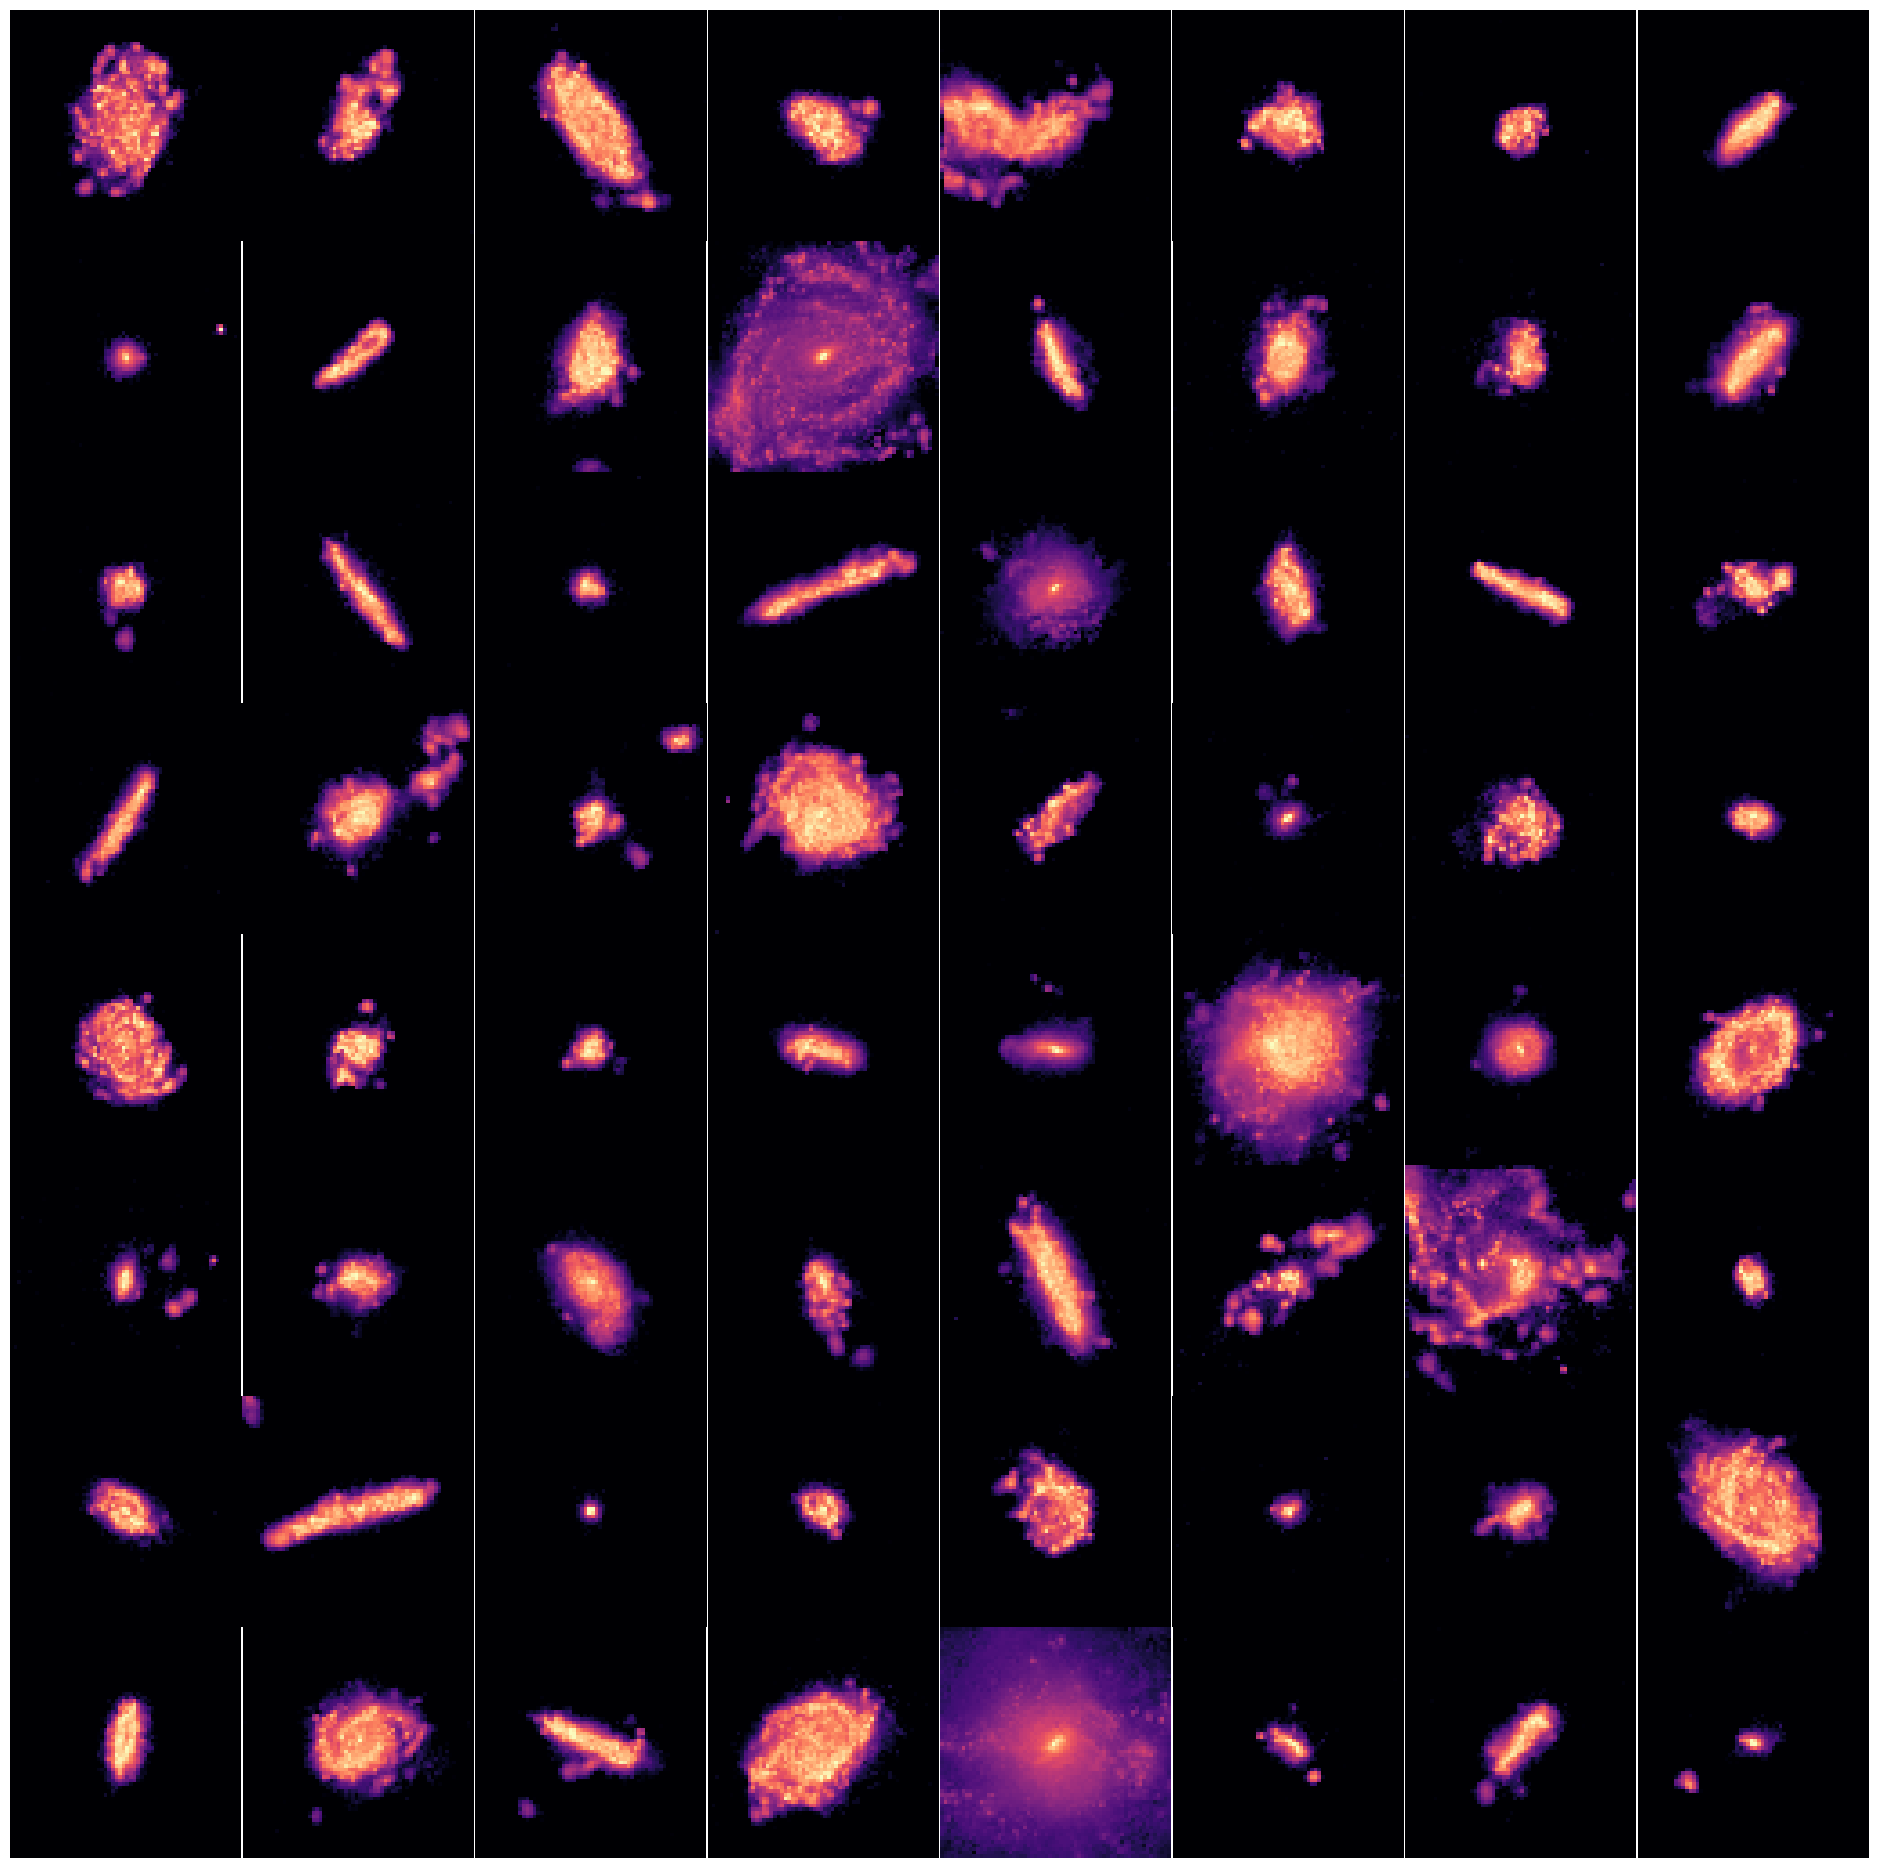

In [20]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = i * 8 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma", norm=plt.cm.colors.LogNorm(vmin=5e-3, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_skirt_vp64.png")

# $128 \times 128$ VP trained in linear space 

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(24, 24))
for i in range(4):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_skirt_vp128_y.png")

# $256 \times 256$ VP trained in linear

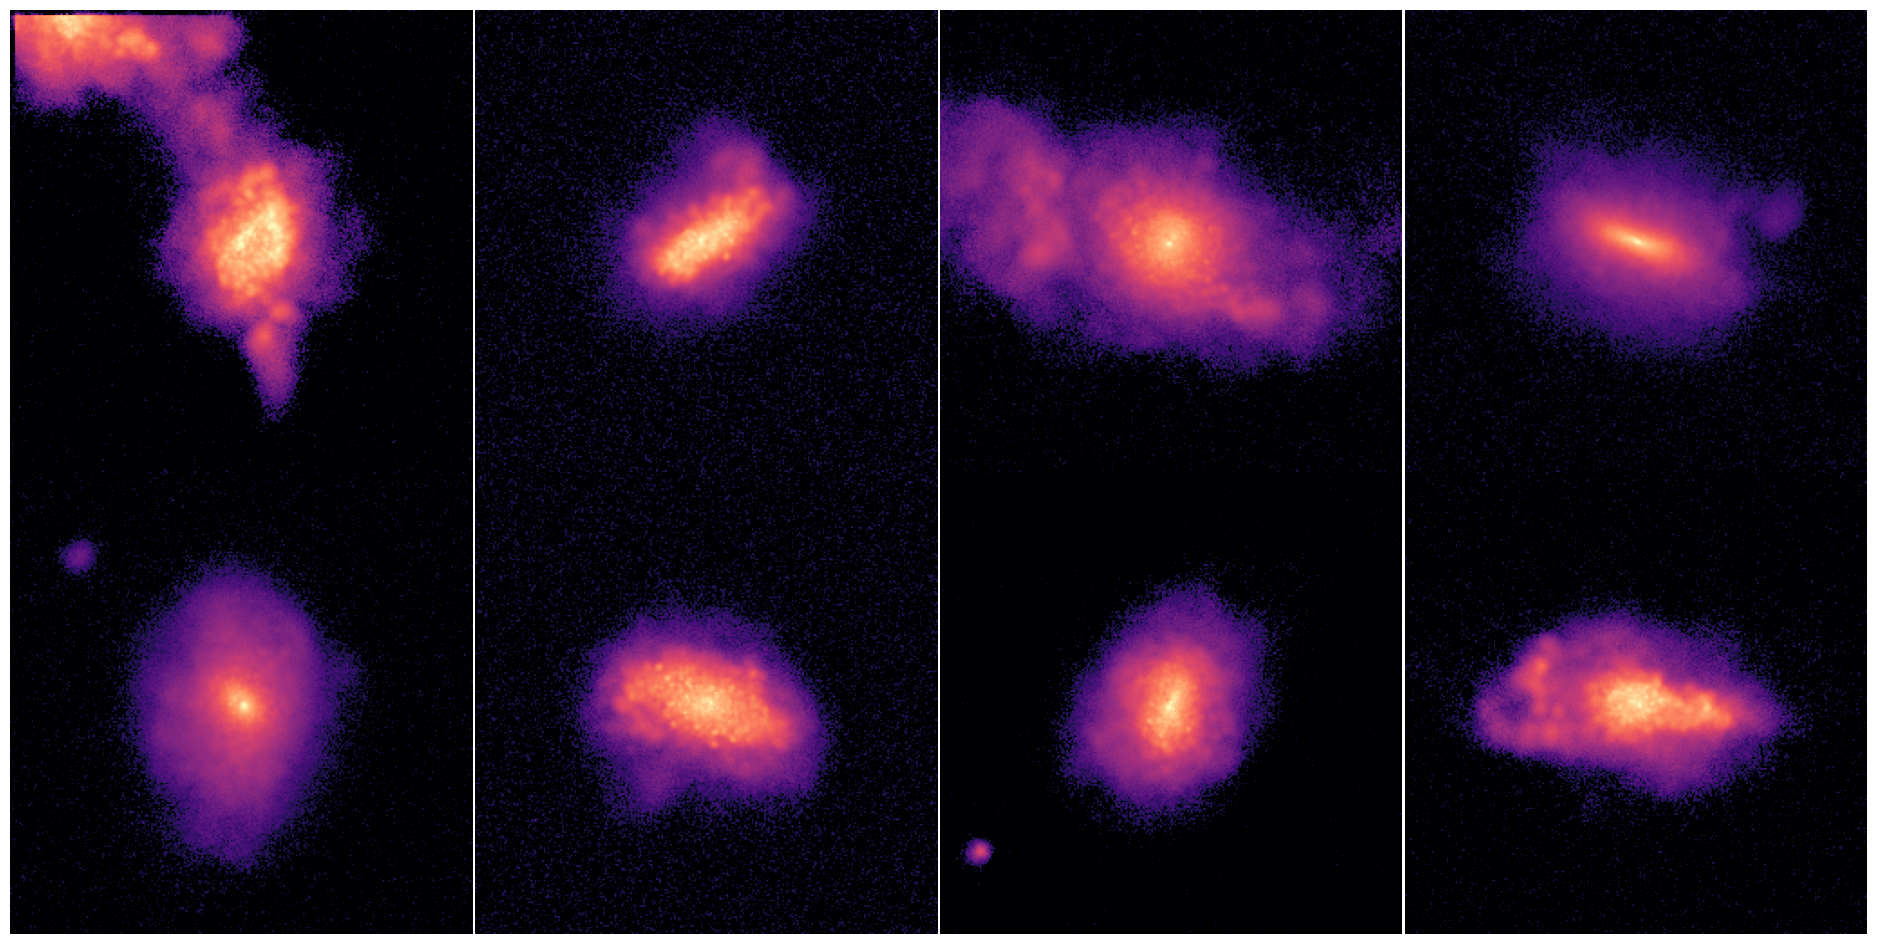

In [13]:
fig, axs = plt.subplots(2, 4, figsize=(24, 12))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_skirt_vp256_y.png")

# $64 \times 64$ VE trained in log space

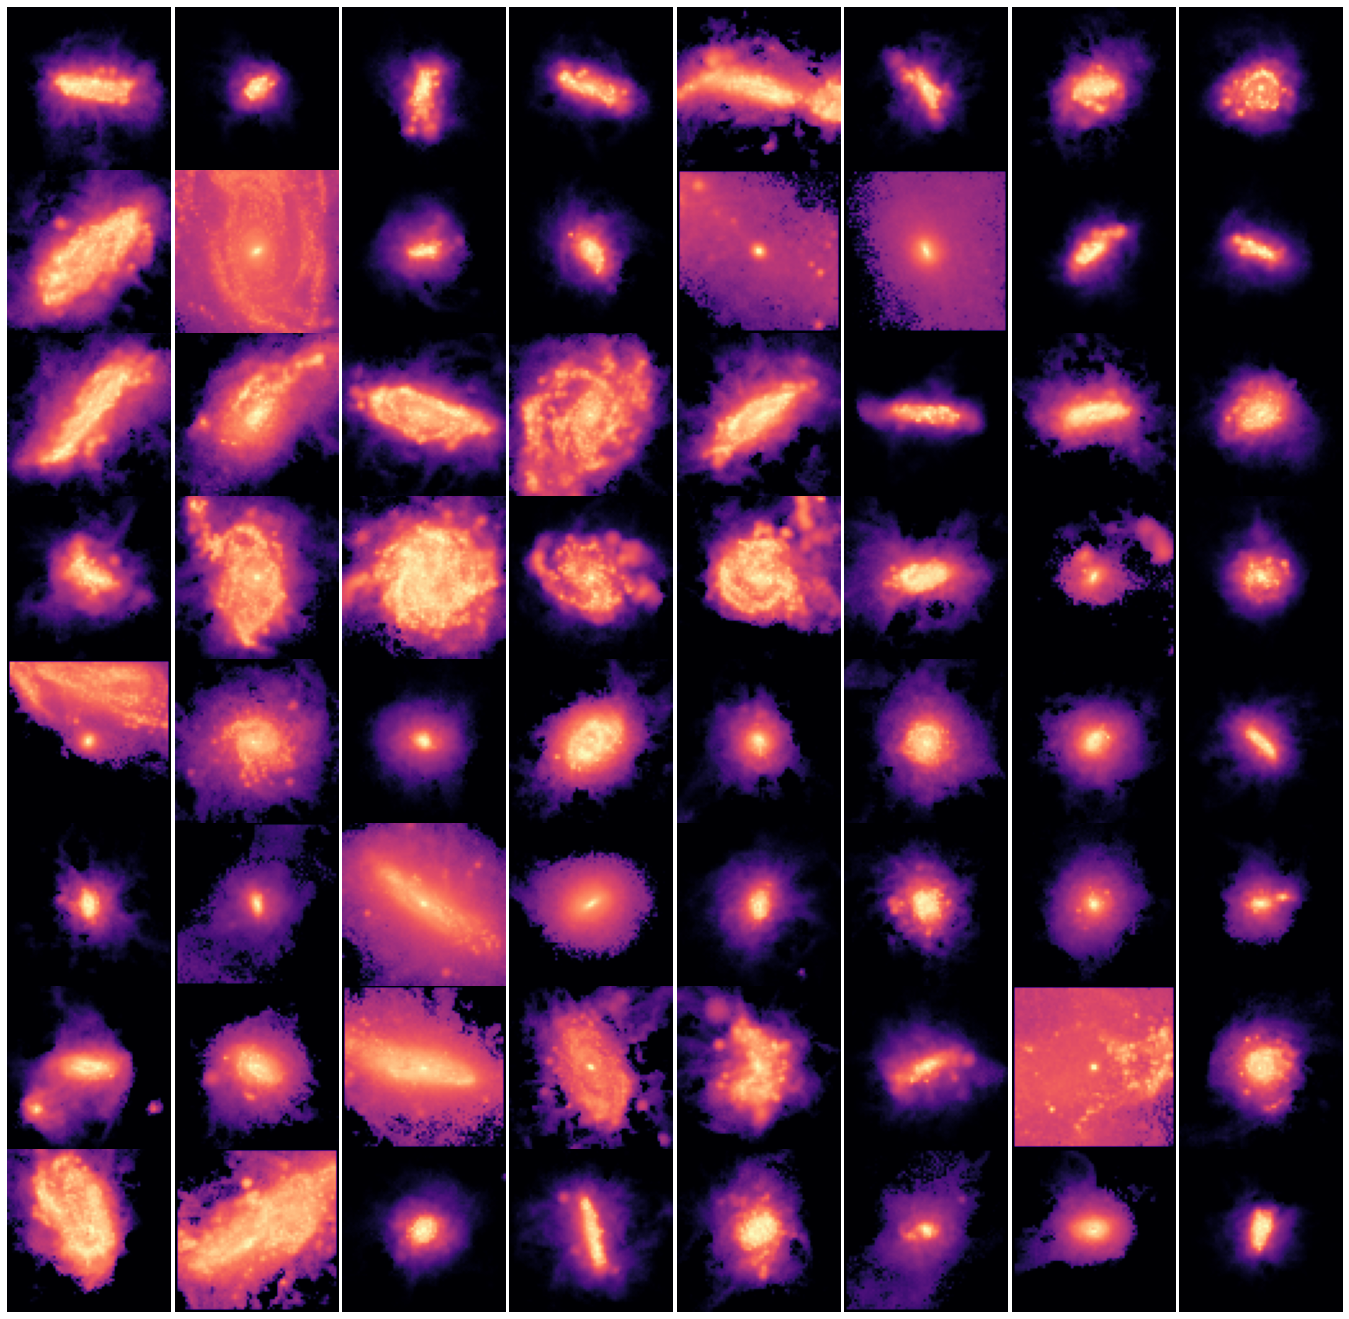

In [26]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = i * 8 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_illustris_score_64.png")

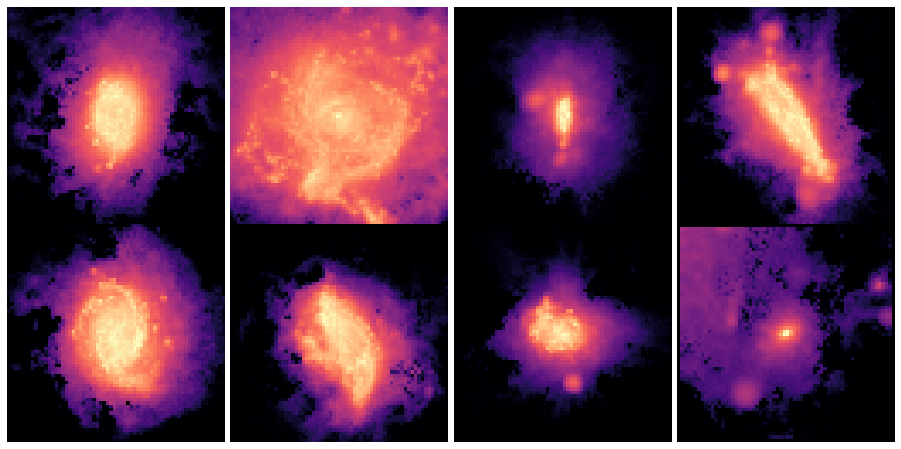

In [14]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 128

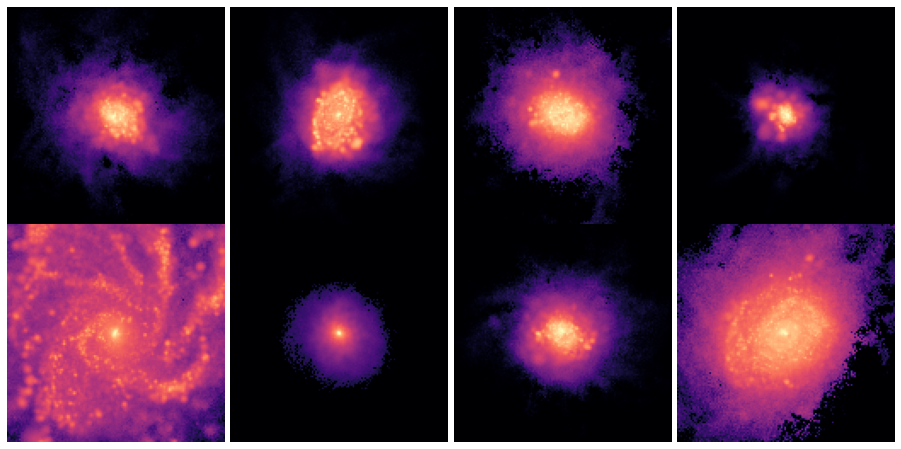

In [28]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# 256

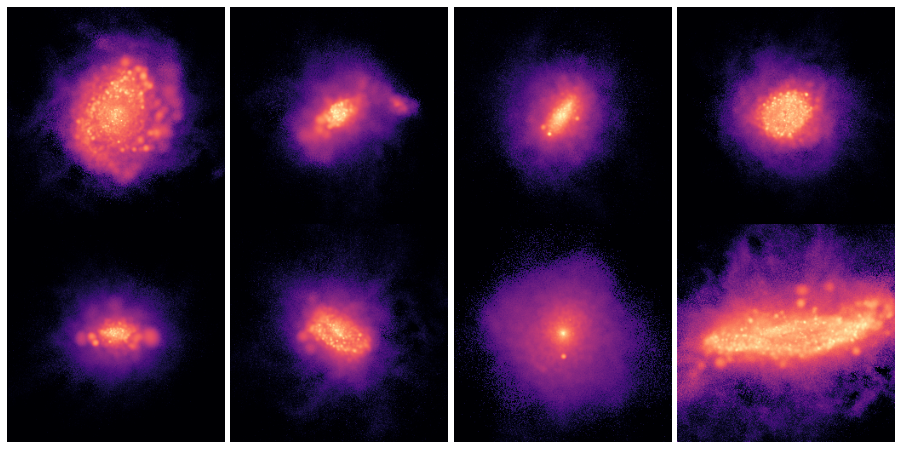

In [10]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i in range(2):
    for j in range(4):
        k = i * 4 + j
        axs[i, j].imshow(samples[k, 0].cpu(), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Data

In [24]:
path = "/home/aadam/scratch/skirt64_grizy.h5"
data = h5py.File(path)

def ab_mag_to_jansky_per_arcsec_squared(img):
    return 10**(-(img - 8.9) / 2.5)

def preprocessing(img, dynamic_range=1e5):
    """
    We want the diffusion to happen in log space so that generated images
    strictly have positive flux.

    We use log10(10 micro Jansky / arcsec^2) units instead of AB mag.

    dynamic_range: Sets the decimal value, in Jansky, up to which we hope to model the surface
        brightness. This preprocessing destroys the information below the dynamic range,
        or too faint by our criteria.
    In the end, most pixel values should roughly fall in the range
    [0, log10(dynamic_range)].
    """
    img = ab_mag_to_jansky_per_arcsec_squared(img)
    return np.log(1e5 * img + 1/dynamic_range) / np.log(10.) + np.log10(dynamic_range)

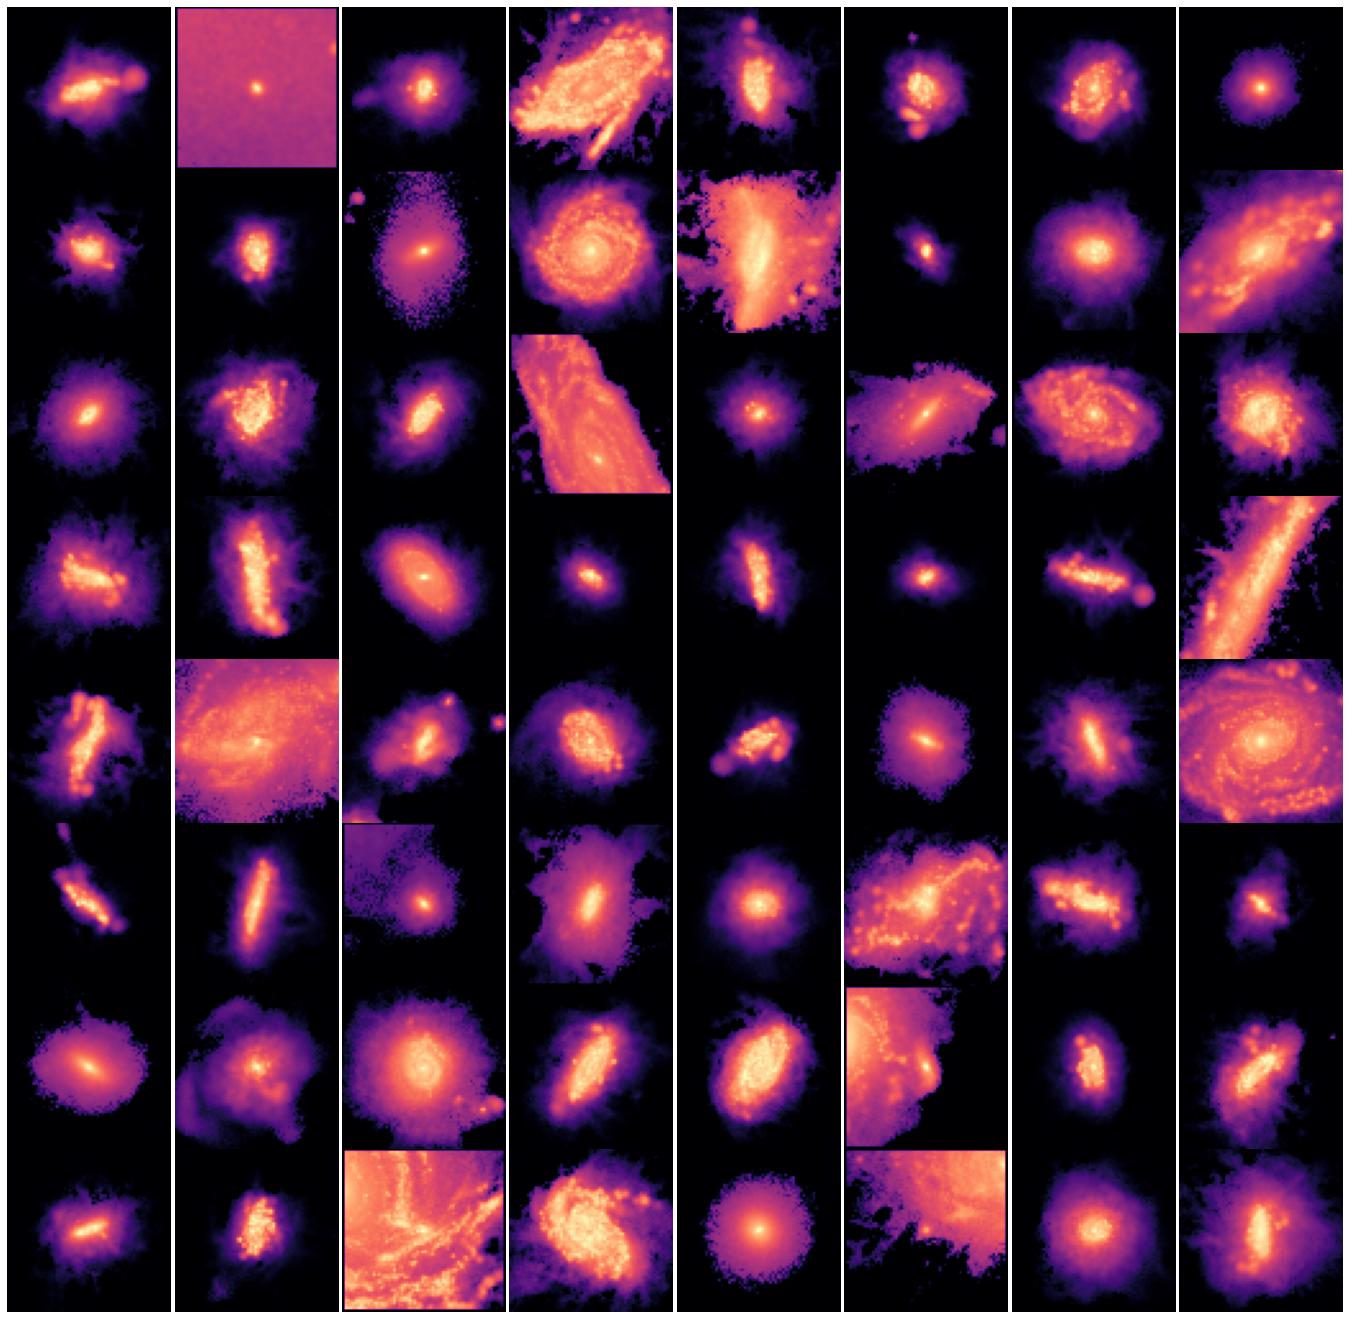

In [27]:
fig, axs = plt.subplots(8, 8, figsize=(24, 24))
for i in range(8):
    for j in range(8):
        k = np.random.randint(data["images"].shape[0])
        axs[i, j].imshow(preprocessing(data["images"][k, 0]), cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("../results/samples_illustris_data_64.png")